In [ ]:
%%writefile requirements.txt
# Deep Learning
torch
torchvision

# Scientific Computing
numpy
matplotlib
scikit-learn
scikit-image

# Quantum Computing
qiskit
qiskit-machine-learning

In [ ]:
!pip install -r requirements.txt


<table>
<tr>
<td><img src="https://raw.githubusercontent.com/RafaelCaballero/tdm/refs/heads/master/images/logoSPB.png" width="240"></td>
<td><table><tr><td><h1>Procesamiento de Imagenes: Clasificacion de Ruido y Denoising</h1></td></tr>
           <tr><td><h3>Hybrid Convolutional Neural Network + Quantum Neural Network for mixed noise classification and denoising with a Hybrid VQAE</h3></td></tr></table></td>
</tr>
</table>

**Objetivos**:
1. **Clasificacion de imagenes con ruido mixto**: entrenar una CNN clasica y una QNN hibrida para identificar la combinacion de distorsiones (Gaussiano, Sal y Pimienta, Speckle).
2. **Denoising**: implementar un VAE hibrido (Conv + QNN) para reconstruir imagenes limpias a partir de versiones degradadas.
3. **Comparativa clasico vs hibrido**: analizar diferencias de rendimiento y coste computacional.
4. **Extra**: discutir el rol del embedding angular y los observables en el rendimiento del modelo.

**Indice**:
1. **Introduccion y preprocesamiento de datos**

    1.1. Planteamiento del problema

    1.2. Modelizacion del ruido

2. **Clasificacion de ruido con CNN + QNN**

    2.1. Construccion del QNN (feature map, ansatz, observables)

    2.2. Arquitectura hibrida y espacio latente

    2.3. Bucle de entrenamiento y evaluacion

3. **Denoising con VAE hibrido (ConvHQVAE)**

    3.1. Estructura del encoder/decoder

    3.2. Truco de la reparametrizacion y funcion de perdida

4. **Resultados y Conclusiones**

## 1. Introduccion y preprocesamiento de datos

### 1.1. Planteamiento del problema

En este notebook se replica el flujo del modelo clasico, pero sustituyendo parte del procesamiento por una **red cuantica parametrizada (QNN)**. El objetivo es comparar el comportamiento de una CNN clasica frente a un enfoque hibrido en dos tareas:
- **Clasificacion de ruido mixto** en MNIST.
- **Denoising** mediante un VAE hibrido.

Se trabaja con subconjuntos pequenos para acelerar el entrenamiento en simulacion cuantica.

- training dataset: 400 muestras (300 train, 100 validation).
- test dataset: 100 muestras.

**TO DO**: ajustar esta seccion si cambian las particiones o se emplean mas datos.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import cat
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn import (
    Module,
    Conv2d,
    Linear,
    Dropout2d,
    NLLLoss,
    MaxPool2d,
    Flatten,
    Sequential,
    ReLU,
    Identity
)
import torch.nn.functional as F

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from common_utils import plot_training_curves, plot_confusion_matrix, evaluate_model, mostrar_reconstrucciones

from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit import QuantumCircuit
from qiskit_machine_learning.connectors import TorchConnector


In [ ]:
transform = transforms.Compose([transforms.ToTensor()])
X_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
X_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

In [ ]:
n_samples_train = 400
n_samples_test = 100

X_train.data = X_train.data[:n_samples_train]
X_train.targets = X_train.targets[:n_samples_train]

X_test.data = X_test.data[:n_samples_test]
X_test.targets = X_test.targets[:n_samples_test]

In [ ]:
train_size = 300
val_size = 100

train_subset, val_subset = random_split(X_train, [train_size, val_size])

### 1.2. Modelizacion del ruido

Se reutilizan tres funciones de degradacion estocastica sobre la imagen original $x$:

#### Ruido Gaussiano
Ruido blanco aditivo con desviacion estandar $\sigma = 0.25$, acotando el resultado en $[0,1]$:
$$
x_{\text{gaussian}} = \max\left(0, \min\left(1, x + \mathcal{N}(0, \sigma^2)\right)\right)
$$

#### Ruido de Sal y Pimienta (Impulsivo)
Modifica una fraccion probabilistica de pixeles ($\text{prob} = 0.15$), asignando 0 o 1 de forma equiprobable.

#### Ruido Speckle (Multiplicativo)
Ruido proporcional a la intensidad del pixel con $\sigma = 0.35$:
$$
x_{\text{speckle}} = \max\left(0, \min\left(1, x + x \cdot \mathcal{N}(0, \sigma^2)\right)\right)
$$

Las combinaciones de ruido definen las clases de destino:

| Clase | Combinacion de Ruido Aplicada |
|-------|-------------------------------|
| 0     | Gaussiano + Speckle |
| 1     | Gaussiano + Sal y Pimienta |
| 2     | Sal y Pimienta + Speckle |

In [ ]:
def gaussian_noise(img, sigma=0.25): # antes 0.1
    noise = torch.randn_like(img) * sigma
    return torch.clamp(img + noise, 0, 1)

def salt_pepper(img, prob=0.15): # antes 0.05
    noisy = img.clone()

    mask = torch.rand_like(img)

    noisy[mask < prob/2] = 0
    noisy[mask > 1 - prob/2] = 1

    return noisy

def speckle(img, sigma=0.35): # antes 0.2
    noise = torch.randn_like(img) * sigma
    return torch.clamp(img + img * noise, 0, 1)


def apply_mixed_noise(img):
    r = np.random.randint(3)

    # gaussian + speckle
    if r == 0:
        img = gaussian_noise(img)
        img = speckle(img)
        label = 0

    # gaussian + salt & pepper
    elif r == 1:
        img = gaussian_noise(img)
        img = salt_pepper(img)
        label = 1

    # salt & pepper + speckle
    else:
        img = salt_pepper(img)
        img = speckle(img)
        label = 2

    return img, label


In [ ]:
class NoisyMNISTDataset(Dataset):
    def __init__(self, mnist_dataset):
        self.mnist = mnist_dataset

        # Aquí preprocesamos todas las imágenes y guardamos el ruido y las etiquetas
        self.noisy_images = []
        self.labels = []

        for img, _ in self.mnist:
            noisy_img, label = apply_mixed_noise(img)
            self.noisy_images.append(noisy_img)
            self.labels.append(label)

        # Comprobación de consistencia
        if len(self.noisy_images) != len(self.labels):
            raise Exception("Incompatible arrays")


    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        return self.noisy_images[idx], self.labels[idx]


train_dataset = NoisyMNISTDataset(train_subset)
val_dataset = NoisyMNISTDataset(val_subset)
test_dataset = NoisyMNISTDataset(X_test)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

images, labels = next(iter(train_loader))

print(images.shape)  # [32, 1, 28, 28]
print(labels.shape)


torch.Size([32, 1, 28, 28])
torch.Size([32])


### 2. Clasificacion de ruido con CNN + QNN

### 2.1. Construccion del QNN (feature map, ansatz, observables)

El bloque cuantico utiliza un **feature map** para codificar el vector de 4 dimensiones y un **ansatz** parametrizado para aprender una transformacion no lineal. Se miden **observables** para obtener los logits de clasificacion.

- Feature map: `zz_feature_map` con entrelazamiento completo.
- Ansatz: `real_amplitudes` con entrelazamiento lineal.
- Observables: combinaciones de Pauli Z para extraer expectativas.

**TO DO**: justificar la eleccion exacta de observables y reps con resultados experimentales.

In [ ]:
# from qiskit.quantum_info import Pauli
# from qiskit.quantum_info import SparsePauliOp


# observables = [
# SparsePauliOp.from_list([("ZIII", 1.0), ("IZII", 1.0)]),
# SparsePauliOp.from_list([("ZZII", 1.0)]),
# SparsePauliOp.from_list([("IIZZ", 1.0)])
# ] # mejor resultado

# estimator = Estimator()
# def create_qnn():
#     feature_map = zz_feature_map(4, entanglement="full", reps=1)
#     ansatz = real_amplitudes(4, entanglement="reverse_linear", reps=1)
#     qc = QuantumCircuit(4)
#     qc.compose(feature_map, inplace=True)
#     qc.compose(ansatz, inplace=True)


#     # REMEMBER TO SET input_gradients=True FOR ENABLING HYBRID GRADIENT BACKPROP
#     qnn = EstimatorQNN(
#         circuit=qc,
#         input_params=feature_map.parameters,
#         weight_params=ansatz.parameters,
#         input_gradients=True,
#         estimator=estimator,
#         observables=observables
#     )
#     return qnn


# qnn = create_qnn()

# qnn.circuit.draw("mpl")

In [ ]:
# qnn.weight_params

In [ ]:
# qnn.input_params

### 2.2. Arquitectura hibrida y espacio latente

La CNN clasica actua como extractor de caracteristicas y proyecta la salida a un vector latente de 4 dimensiones. Ese vector se reescala a $[-\pi, \pi]$ para su uso como **embedding angular** en el QNN.

- Convoluciones: `Conv2d(1 -> 16)` y `Conv2d(16 -> 32)` con `MaxPool2d`.
- Proyeccion: `fc1` a 128 y `fc2` a 4.
- QNN: `TorchConnector(qnn)` devuelve expectativas para 3 clases.

**TO DO**: incluir diagrama de la arquitectura hibrida y explicar el flujo completo.

In [ ]:
# class Net(nn.Module):
#     def __init__(self, qnn):
#         super().__init__()
#         # 2 capas convolucionales
#         self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
#         self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
#         self.pool = nn.MaxPool2d(2)

#         # fully connected
#         self.fc1 = nn.Linear(32*7*7, 128)  # flatten 32×7×7=1568
#         self.fc2 = nn.Linear(128, 4)      # vector final 4D para QNN

#         # QNN
#         self.qnn = TorchConnector(qnn)
#         # 3Capa lineal final (mapear expectation values → logits 3 clases)
#         self.fc_final = nn.Identity()
#         # Linear(len(qnn.observables), 3)
#     def forward(self, x):
#         # Extracción de features clásicas
#         x = F.relu(self.conv1(x))
#         x = self.pool(x)
#         x = F.relu(self.conv2(x))
#         x = self.pool(x)

#         # Flatten y proyección fully connected
#         x = x.view(x.shape[0], -1)
#         x = F.relu(self.fc1(x))
#         x = torch.tanh(self.fc2(x)) * np.pi

#         # Forward QNN
#         x = self.qnn(x)
#         # Capa lineal final → logits:
#         x = self.fc_final(x)
#         return x

# hqnn = Net(qnn)

In [ ]:
# import torch
# print(torch.cuda.is_available())

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# hqnn.to(device)

### 2.3. Bucle de entrenamiento y evaluacion

Se entrena con `CrossEntropyLoss`, que espera logits sin `softmax`. Se monitorizan perdida y accuracy en train/val, y se evalua con matriz de confusion sobre el conjunto de test.

**TO DO**: anadir comentarios sobre estabilidad del entrenamiento y tiempos de ejecucion.

In [ ]:
# # Separar parámetros correctamente
# optimizer = optim.Adam(hqnn.parameters(), lr=0.001)
# criterion = nn.CrossEntropyLoss()
# # CrossEntropyLoss: combina LogSoftmax + NLLLoss, por lo que espera logits sin softmax
# # logits = raw outputs del modelo, sin softmax
# # LogSoftmax: convierte logits en probabilidades logarítmicas
# # NLLLoss: calcula la pérdida negativa logarítmica entre las probabilidades logarítmicas y las etiquetas verdaderas

# epochs = 10
# # Lista para guardar pérdidas de entrenamiento y validación
# train_loss_list = []
# val_loss_list = []

# # Lista para guardar accuracies
# train_acc_list = []
# val_acc_list = []

# for epoch in range(epochs):
#     ##############################
#     # Entrenamiento
#     ##############################
#     hqnn.train()  # modo entrenamiento
#     total_loss = 0
#     correct = 0
#     total = 0

#     for data, target in train_loader:
#         data, target = data.to(device), target.to(device)

#         optimizer.zero_grad()          # reset gradientes
#         output = hqnn(data)            # forward pass
#         loss = criterion(output, target)
#         loss.backward()                # backprop
#         optimizer.step()               # update pesos

#         total_loss += loss.item() * data.size(0)  # sumar pérdida
#         _, predicted = torch.max(output, 1)
#         correct += (predicted == target).sum().item()
#         total += target.size(0)

#     avg_train_loss = total_loss / total
#     train_acc = correct / total
#     train_loss_list.append(avg_train_loss)
#     train_acc_list.append(train_acc)


#     # Validación
#     hqnn.eval()  # modo evaluación
#     val_loss = 0
#     correct = 0
#     total = 0

#     with torch.no_grad():  # no calculamos gradientes
#         for data, target in val_loader:
#             data, target = data.to(device), target.to(device)
#             output = hqnn(data)
#             loss = criterion(output, target)

#             val_loss += loss.item() * data.size(0)
#             _, predicted = torch.max(output, 1)
#             correct += (predicted == target).sum().item()
#             total += target.size(0)

#     avg_val_loss = val_loss / total
#     val_acc = correct / total
#     val_loss_list.append(avg_val_loss)
#     val_acc_list.append(val_acc)

#     # Mostrar métricas
#     print(f"Epoch {epoch+1}/{epochs} | "
#           f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
#           f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

In [ ]:
# plot_training_curves(train_loss_list, val_loss_list, train_acc_list, val_acc_list)

In [ ]:
# results = evaluate_model(hqnn, test_loader, device)

# print("Accuracy:", results["accuracy"])
# print(results["report"])

# plot_confusion_matrix(results["confusion_matrix"],
#                       ["class 0", "class 1", "class 2"])

## 1. CLASSICAL PARA PROBAR LUEGO HQVAE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import cat
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn import (
    Module,
    Conv2d,
    Linear,
    Dropout2d,
    NLLLoss,
    MaxPool2d,
    Flatten,
    Sequential,
    ReLU,
)
import torch.nn.functional as F

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from common_utils import plot_training_curves, plot_confusion_matrix, evaluate_model, mostrar_reconstrucciones

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])


X_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
X_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

In [ ]:
n_samples_train = 400
n_samples_test = 100

X_train.data = X_train.data[:n_samples_train]
X_train.targets = X_train.targets[:n_samples_train]

X_test.data = X_test.data[:n_samples_test]
X_test.targets = X_test.targets[:n_samples_test]

In [ ]:
train_size = 300
val_size = 100

train_subset, val_subset = random_split(X_train, [train_size, val_size])

In [ ]:
class ClassicalNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,16,5,padding=2)
        self.conv2 = nn.Conv2d(16,32,5,padding=2)
        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(32*7*7,128)
        self.fc2 = nn.Linear(128,4)

        # equivalente al espacio cuántico
        self.feature_mixer = nn.Sequential(
            nn.Linear(4,16),
            nn.Tanh(),

            nn.Linear(16,16),
            nn.Tanh(),

            nn.Linear(16,3)
        )

    def forward(self,x):

        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0),-1)

        x = F.relu(self.fc1(x))

        x = torch.tanh(self.fc2(x)) * np.pi

        x = self.feature_mixer(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ClassicalNet().to(device)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

epochs = 10

train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

for epoch in range(epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    # validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item() * x.size(0)
            val_correct += (out.argmax(1) == y).sum().item()
            val_total += y.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/10 | Train Loss: 1.0981 | Train Acc: 0.3900 | Val Loss: 1.0833 | Val Acc: 0.3600
Epoch 2/10 | Train Loss: 1.0597 | Train Acc: 0.4667 | Val Loss: 1.0531 | Val Acc: 0.3800
Epoch 3/10 | Train Loss: 1.0101 | Train Acc: 0.5567 | Val Loss: 0.9253 | Val Acc: 0.6900
Epoch 4/10 | Train Loss: 0.8671 | Train Acc: 0.7133 | Val Loss: 0.7797 | Val Acc: 0.8500
Epoch 5/10 | Train Loss: 0.6797 | Train Acc: 0.8700 | Val Loss: 0.6120 | Val Acc: 0.9500
Epoch 6/10 | Train Loss: 0.5318 | Train Acc: 0.9333 | Val Loss: 0.4500 | Val Acc: 0.9400
Epoch 7/10 | Train Loss: 0.3972 | Train Acc: 0.9733 | Val Loss: 0.3347 | Val Acc: 0.9800
Epoch 8/10 | Train Loss: 0.3096 | Train Acc: 0.9800 | Val Loss: 0.2620 | Val Acc: 0.9900
Epoch 9/10 | Train Loss: 0.2318 | Train Acc: 1.0000 | Val Loss: 0.2154 | Val Acc: 0.9900
Epoch 10/10 | Train Loss: 0.1920 | Train Acc: 0.9967 | Val Loss: 0.1625 | Val Acc: 1.0000


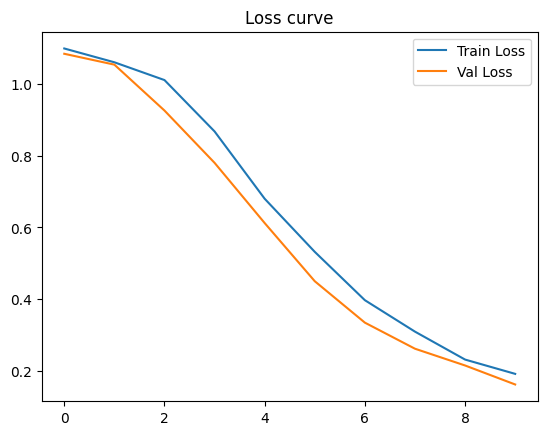

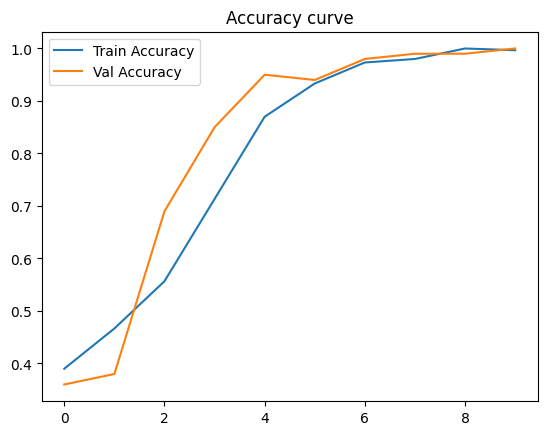

In [ ]:
plot_training_curves(train_loss_list, val_loss_list, train_acc_list, val_acc_list)

## 3. Denoising con VAE hibrido (ConvHQVAE)

Se reutiliza el dataset ruidoso, pero ahora el objetivo es reconstruir la imagen limpia. El encoder es convolucional y el espacio latente se procesa mediante un QNN antes del decoder.

**TO DO**: justificar la dimension latente y el numero de qubits.

In [ ]:
class DenoisingMNISTDataset(Dataset):
    def __init__(self, mnist_dataset):
        self.mnist = mnist_dataset
        self.noisy_images = []
        self.clean_images = []

        for img, _ in self.mnist:
            clean_img = img
            noisy_img, _ = apply_mixed_noise(img)
            self.clean_images.append(clean_img)
            self.noisy_images.append(noisy_img)

    def __len__(self):
        return len(self.mnist)

    def __getitem__(self, idx):
        return self.noisy_images[idx], self.clean_images[idx]

In [ ]:
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.circuit.library import real_amplitudes, zz_feature_map
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit_machine_learning.connectors import TorchConnector
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import pauli_feature_map

estimator = Estimator()
observables = [

    SparsePauliOp.from_list([("XIII",1)]),
    SparsePauliOp.from_list([("YIII",1)]),

    SparsePauliOp.from_list([("IXII",1)]),
    SparsePauliOp.from_list([("IYII",1)]),

    SparsePauliOp.from_list([("ZZII",1)]),

    SparsePauliOp.from_list([("IIZZ",1)])
]
def create_qnn_vae():
    n_qubits = 4
    feature_map = pauli_feature_map(feature_dimension=4, paulis=['X','Y','ZZ'], reps=2, entanglement="full")
    ansatz = real_amplitudes(n_qubits, entanglement="full", reps=1)
    qc = QuantumCircuit(n_qubits)
    qc.compose(feature_map, inplace=True)
    qc.compose(ansatz, inplace=True)

    qnn = EstimatorQNN(
        circuit=qc,
        input_params=feature_map.parameters,
        weight_params=ansatz.parameters,
        input_gradients=True,
        estimator=estimator,
        observables=observables
    )
    return qnn

qnn_vae = create_qnn_vae()

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


### 3.1. Estructura del encoder y decoder

El ConvHQVAE combina un encoder convolucional clasico con un bloque cuantico que transforma el vector latente. La salida cuantica se concatena con el propio latente para preservar informacion antes de decodificar.

- Encoder: `Conv2d(1 -> 32 -> 64)` + `Flatten`.
- Espacio latente: `fc_mu`, `fc_logvar`.
- QNN: `EstimatorQNN` con 6 qubits y observables en Z.
- Decoder: `ConvTranspose2d` hasta reconstruir $1 \times 28 \times 28$.

**TO DO**: agregar un esquema visual del pipeline ConvHQVAE.

In [ ]:
class ConvHQVAE(nn.Module):
    def __init__(self, latent_dim=4, qnn=None):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(3136, latent_dim)
        self.fc_logvar = nn.Linear(3136, latent_dim)

        self.qnn = TorchConnector(qnn) if qnn is not None else nn.Identity()

        # Ahora fc_decode recibe latent + salida QNN
        self.fc_decode = nn.Linear(latent_dim + len(observables), 3136)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64,7,7)),
            nn.ConvTranspose2d(64,32,4,stride=2,padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32,1,4,stride=2,padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparametrize(self, mu, logvar):
        sigma = torch.exp(0.5*logvar)
        return mu + sigma*torch.randn_like(sigma)

    def decode(self, z):
        z_qnn = self.qnn(z)
        # Concatenamos para que no se pierda información
        z_combined = torch.cat([z, z_qnn], dim=1)
        return self.decoder(self.fc_decode(z_combined))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparametrize(mu, logvar)
        return self.decode(z), mu, logvar

In [ ]:
train_dataset_dn = DenoisingMNISTDataset(train_subset)
val_dataset_dn   = DenoisingMNISTDataset(val_subset)
test_dataset_dn  = DenoisingMNISTDataset(X_test)

train_loader_dn = DataLoader(train_dataset_dn, batch_size=32, shuffle=True)
val_loader_dn   = DataLoader(val_dataset_dn, batch_size=32, shuffle=False)
test_loader_dn  = DataLoader(test_dataset_dn, batch_size=32, shuffle=False)

### 3.2. Truco de la reparametrizacion y funcion de perdida

En un autoencoder variacional, el encoder no devuelve un unico punto latente, sino una distribucion aproximada:
$$
q_\phi(z \mid x) = \mathcal{N}\left(\mu_\phi(x), \sigma_\phi(x)^2\right)
$$

El encoder produce $\mu_\phi(x)$ y $\mathrm{logvar}_\phi(x) = \log\left(\sigma_\phi(x)^2\right)$, y la desviacion tipica se recupera con:
$$
\sigma_\phi(x) = \exp\left(\frac{1}{2}\mathrm{logvar}_\phi(x)\right)
$$

Para permitir backpropagation, se aplica el truco de reparametrizacion:
$$
z = \mu_\phi(x) + \sigma_\phi(x) \odot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)
$$

El prior latente es $p(z) = \mathcal{N}(0, I)$ y la funcion objetivo se basa en la ELBO:
$$
\mathrm{ELBO}(q_\phi) = \mathbb{E}_{q_\phi(z \mid x)}\left[\log p_\theta(x \mid z)\right] - \mathrm{KL}\left(q_\phi(z \mid x) \| p(z)\right)
$$

En este notebook se utiliza una perdida tipo $\beta$-VAE:
$$
\mathcal{L}_{\text{total}} = \text{BCE}(x, \hat{x}) + \beta \cdot \mathcal{D}_{\text{KL}}\left(\mathcal{N}(\mu, \sigma^2) \parallel \mathcal{N}(0, I)\right)
$$

**TO DO**: explicar la eleccion de $\beta$ y su impacto en la reconstruccion.

In [ ]:
def vae_loss(recon_x, x, mu, logvar, beta=0.5):
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kl  = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + beta * kl

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_hqvae = ConvHQVAE(latent_dim=4, qnn=qnn_vae).to(device)
optimizer = optim.Adam(model_hqvae.parameters(), lr=1e-3)
EPOCHS = 15  # se puede reducir para pruebas rápidas

for epoch in range(1, EPOCHS+1):
    model_hqvae.train()
    total_loss = 0
    for noisy, clean in train_loader_dn:
        noisy, clean = noisy.to(device), clean.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model_hqvae(noisy)
        loss = vae_loss(recon, clean, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch} | Loss: {total_loss/len(train_loader_dn.dataset):.4f}")

Epoch 1 | Loss: 459.0835
Epoch 2 | Loss: 338.8242


## 4. Resultados y Conclusiones

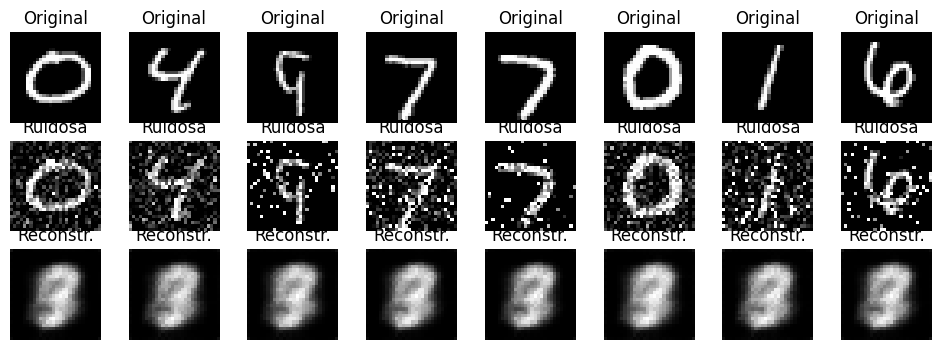

In [ ]:
mostrar_reconstrucciones(model_hqvae, test_dataset_dn, n=8, device=device)  # VAE híbrido

**TO DO**: describir  las reconstrucciones (nitidez, borrado de ruido, fallos tipicos) y comparar con el VAE clasico.

### 4.1. Métricas de evaluación

Para medir si el ConvVAE reconstruye correctamente las imágenes “limpias” a partir de las ruidosas, se utilizan métricas cuantitativas de error:

- #### Mean Squared Error (MSE)
    $$
    \text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (x_i - \hat{x}_i)^2
    $$

    Compara píxel a píxel la reconstrucción ($\hat{x}$) con la imagen original ($x$).  
    Valores más bajos indican mejor reconstrucción.


- #### Peak Signal-to-Noise Ratio (PSNR)
    $$
    \text{PSNR} = 10 \cdot \log_{10} \left( \frac{\text{MAX}^2}{\text{MSE}} \right)
    $$

    donde $\text{MAX}$ es el valor máximo del píxel (para MNIST = 1).  
    Mayor PSNR significa mejor calidad visual.


- #### Structural Similarity Index (SSIM)
    Evalúa similitud estructural entre la imagen original y la reconstruida.  
    Valores cercanos a 1 indican alta similitud.

In [ ]:
from sklearn.metrics import mean_squared_error
import torch
import numpy as np

model_hqvae.eval()
mse_list = []
psnr_list = []

with torch.no_grad():
    for noisy, clean in test_loader_dn:
        noisy, clean = noisy.to(device), clean.to(device)
        recon, _, _ = model_hqvae(noisy)

        # Convertir a numpy
        recon_np = recon.cpu().numpy()
        clean_np = clean.cpu().numpy()

        # MSE
        mse = ((recon_np - clean_np) ** 2).mean()
        mse_list.append(mse)

        # PSNR
        psnr = 10 * np.log10(1.0 / mse)  # MAX=1 para MNIST
        psnr_list.append(psnr)

print(f"MSE promedio: {np.mean(mse_list):.4f}")
print(f"PSNR promedio: {np.mean(psnr_list):.2f} dB")

MSE promedio: 0.0659
PSNR promedio: 11.81 dB


In [ ]:
from skimage.metrics import structural_similarity as ssim
import numpy as np

model_hqvae.eval()
ssim_list = []

with torch.no_grad():
    for noisy, clean in test_loader_dn:
        noisy, clean = noisy.to(device), clean.to(device)
        recon, _, _ = model_hqvae(noisy)

        # Convertir a numpy y dimension [batch, H, W]
        recon_np = recon.squeeze(1).cpu().numpy()
        clean_np = clean.squeeze(1).cpu().numpy()

        for i in range(recon_np.shape[0]):
            ssim_val = ssim(clean_np[i], recon_np[i], data_range=1.0)
            ssim_list.append(ssim_val)

print(f"SSIM promedio: {np.mean(ssim_list):.4f}")

ModuleNotFoundError: No module named 'skimage'

**TO DO**: interpretar MSE/PSNR/SSIM obtenidos y compararlos con el modelo clasico y con la literatura.